# FAANG Stock Analysis — Winter 25/26 Assessment

### 📘 Introduction
This notebook addresses the Winter 25/26 assessment for the Computer Infrastructure module.  
It demonstrates four core tasks: **data collection, visualisation, scripting, and automation**.  
Through these steps, you will show proficiency in Python programming, reproducible analysis, and CI/CD workflows, using FAANG stock data as a practical case study.

**Assessment Tasks:**
- Fetch hourly OHLCV data for FAANG tickers and save to timestamped CSV files in the `data/` directory.  
- Plot closing prices for each of the five stocks and save the plots as PNG files in the `plots/` directory.  
- Convert notebook logic into a CLI script.  
- Automate execution via GitHub Actions.  

### 📦 Import Libraries
This section imports the Python libraries needed for data manipulation, financial data retrieval, and plotting.

- `pathlib.Path` → Cross‑platform file and folder handling  
- `datetime` → Timestamped filenames for reproducibility  
- `pandas` → Data manipulation and analysis  
- `yfinance` → Financial data API for stock history  
- `matplotlib.pyplot` → Static plotting  
- `seaborn` → Enhanced plotting styles
- `numpy` → Numerical operations

In [1]:
%matplotlib inline

from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### 🛠️ Helper Functions
Reusable functions ensure modularity, reproducibility, and clarity across both the notebook and CLI script.

- verify_environment() → Checks connectivity to the yfinance API by retrieving sample data for Apple (AAPL). Uses exception handling to report errors.
- fetch_hourly_history() → Retrieves 5 days of hourly OHLCV data for a given ticker, formats with datetime index and ticker label.
- save_hourly_data() → Combines data from multiple tickers and saves to a timestamped CSV in the data/ folder. Prevents overwriting unless explicitly allowed.
- load_latest_data() → Loads the most recent CSV file and splits into individual DataFrames per ticker, with optional previews for inspection.

Relevant to: **Problem 1 (Data Collection)** and **Problem 2 (Visualisation)**

References:  
- [Pandas User Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html)  
- [Python Built-in Exceptions](https://docs.python.org/3/library/exceptions.html)
- [yfinance Quickstart](https://pypi.org/project/yfinance/)


In [2]:
# helper function to display dataframes in Jupyter notebooks
# this function checks yfinance connectivity by fetching sample data and optionally displaying it, 
# ensuring the environment is ready for data operations. 
# 📖 [Reference: yfinance Quickstart](https://pypi.org/project/yfinance/)
def verify_environment(show_preview=True):
    """Check yfinance connectivity and preview sample data."""
    try:
        df = yf.Ticker("AAPL").history(period="1d", interval="1h")
        print(f"✅ yfinance test passed — rows: {df.shape[0]}")
        if show_preview:
            display(df.head())
        return True
    except Exception as e:
        print(f"❌ yfinance test failed: {e}")
        return False

# helper function to fetch hourly data for a ticker
# this function retrieves 5 days of hourly OHLCV data for a given ticker and formats it for downstream analysis. 
# 📖 [Reference: yfinance.Ticker.history](https://github.com/ranaroussi/yfinance)
def fetch_hourly_history(ticker):
    """Fetch hourly OHLCV data for a single ticker."""
    try:
        df = yf.Ticker(ticker).history(period='5d', interval='1h')
        if df.empty:
            print(f"⚠️ No data for {ticker}")
            return None
        df['Ticker'] = ticker
        df.index.name = 'Date'
        return df
    except Exception as e:
        print(f"❌ Error fetching {ticker}: {e}")
        return None

# ticker for FAANG stocks
# this function aggregates hourly data for multiple tickers and saves it to a timestamped CSV, 
# supporting reproducibility and version control. 
# 📖 [Reference: pandas.DataFrame.to_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html)
def save_hourly_data(tickers, output_dir, overwrite=False):
    """Save combined hourly data for all tickers to a timestamped CSV."""
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f"📁 Saving to directory: {output_dir}")

    # Fetch data for each ticker
    dfs = []
    for t in tickers:
        df = fetch_hourly_history(t)
        if df is not None and not df.empty:
            print(f"✅ {t}: {len(df)} rows")
            dfs.append(df)
        else:
            print(f"⚠️ {t}: No valid data")

    # Exit if no valid data
    if not dfs:
        print("🚫 No valid data to save.")
        return None

    # Combine and save
    final_df = pd.concat(dfs)
    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    path = output_dir / f"{ts}.csv"

    # Check for overwrite condition
    if path.exists():
        if overwrite:
            print(f"⚠️ Overwriting existing file: {path.name}")
        else:
            print(f"🛑 File already exists and overwrite=False: {path.name}")
            return None

    try:
        final_df.to_csv(path, index_label='Date')
        print(f"✅ Data saved to {path}")
        return str(path)
    except Exception as e:
        print(f"❌ Failed to save file: {e}")
        return None


# helper function to load the latest data file
# this function loads the most recent CSV file and splits it into individual DataFrames per ticker 
# for targeted plotting or analysis. 
# 📖 [Reference: pandas.read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html)
def load_latest_data(tickers, folder='data', show_preview=True):
    """Load the most recent CSV and split into ticker-specific DataFrames."""
    files = sorted(Path(folder).glob("*.csv"), reverse=True)
    if not files:
        raise FileNotFoundError("No CSV files found.")
    df = pd.read_csv(files[0], parse_dates=["Date"])
    data = {t: df[df["Ticker"] == t].copy() for t in tickers}
    if show_preview:
        for t, subdf in data.items():
            print(f"{t}: {subdf.shape}")
            display(subdf.head())
    return data


### ⚙️ Setup & Configuration

This section initialises the environment for data analysis and visualisation.

- **Imports plotting libraries:**
  -  matplotlib.pyplot → Static plots
  -  seaborn → Enhanced aesthetics with grid‑based style

- **Defines global flags:**
  -  SHOW_PREVIEW → Controls whether previews are displayed
  -  OVERWRITE → Prevents overwriting files unless allowed

- **Sets up output directories:**
  -  DATA_DIR → Location for downloaded CSV files
  -  PLOTS_DIR → Location for generated plots

- **Applies consistent plotting style:**
  -  Default figure size for readability
  -  White grid background for clarity

This ensures all subsequent steps produce clear, reproducible plots and store results in an organised structure.

References:

- [matplotlib.pyplot documentation](https://matplotlib.org/stable/api/pyplot_summary.html#module-matplotlib.pyplot)
- [Seaborn aesthetics tutorial](https://seaborn.pydata.org/tutorial/aesthetics.html)


In [3]:
# 🖼️ Plotting Configuration
# The following settings configure the visual style for plots.
# Note: matplotlib.pyplot and seaborn were imported in a previous cell.
# - matplotlib.pyplot is used for creating static line plots.
# - seaborn enhances plot aesthetics and applies a clean grid-based style.

# Global flags
SHOW_PREVIEW = True
OVERWRITE = False

# Output directories
DATA_DIR = Path("data").resolve()
PLOTS_DIR = Path("plots").resolve()

# Plotting style
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')


### ✅ Step 1 — Environment Check

This step confirms that our environment is correctly set up to fetch financial data using the `yfinance` API.  
It is a critical prerequisite for **Problem 1 (Data Collection)** because all later tasks depend on reliable access to hourly stock data.

What this step does:
- **Retrieves hourly data for Apple (AAPL)** to verify that the API connection works.  
- **Shows a preview of the dataset** when `SHOW_PREVIEW` is enabled, so we can visually inspect the structure and confirm the presence of expected columns like `Open`, `High`, `Low`, `Close`, and `Volume`.  
- **Handles errors gracefully** using Python’s `try-except` block, ensuring that any issues (such as connectivity problems) are reported clearly without breaking the workflow.  

By running this check first, we ensure that the system is ready for reproducible data collection and analysis.  
This aligns with best practices in infrastructure automation and prepares the foundation for the rest of the assessment.

Relevant to: **Problem 1 (Data Collection)**  

References:  
- [Python Built-in Exceptions](https://docs.python.org/3/library/exceptions.html)  
- [yfinance Quickstart](https://pypi.org/project/yfinance/)  


In [4]:
# Run environment verification
verify_environment(SHOW_PREVIEW)


✅ yfinance test passed — rows: 7


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2025-11-21 09:30:00-05:00,265.880005,270.450012,265.820007,269.850006,10658658,0.0,0.0
2025-11-21 10:30:00-05:00,269.790009,271.470001,269.220001,270.899994,4761138,0.0,0.0
2025-11-21 11:30:00-05:00,270.890015,271.119995,269.809998,270.549988,2949033,0.0,0.0
2025-11-21 12:30:00-05:00,270.630005,271.600006,270.200012,270.980011,2023820,0.0,0.0
2025-11-21 13:30:00-05:00,270.980011,273.315002,270.864990,272.609985,3562846,0.0,0.0


True

### 📥 Step 2 — Problem 1: Fetch & Save FAANG Data

This cell introduces the **data collection step** of the workflow, where the wrapper function (`get_data()`) calls the helper `save_hourly_data()` to fetch and store reproducible FAANG stock datasets.

- **Helper functionality:**  
  `save_hourly_data()` handles the core tasks:
  - Connecting to the `yfinance` API  
  - Retrieving **hourly OHLCV stock data** for the last 5 days  
  - Creating the `data/` folder if it doesn’t exist  
  - Saving each ticker’s dataset into a timestamped `.csv` file  

- **FAANG tickers:**
  - Facebook → META  
  - Apple → AAPL  
  - Amazon → AMZN  
  - Netflix → NFLX  
  - Google → GOOG  

- **Data collected:** Hourly OHLCV prices, where each `Close` value reflects the hourly closing price per ticker.  
- **Storage:** Saved as `.csv` files in `data/`, each uniquely timestamped (`YYYYMMDD-HHmmss.csv`).  
- **Automation:** Directory creation and file naming are handled automatically by the helper.  

This modular design ensures you always have a **fresh, reproducible dataset** for later problems such as plotting and analysis. By separating responsibilities between `get_data()` and `save_hourly_data()`, the notebook remains clear, maintainable, and aligned with best practices in reproducible workflows.

Relevant to: **Problem 1 (Data Collection)**  

References:  
- [yfinance Documentation](https://pypi.org/project/yfinance/)  
- [pandas.DataFrame.to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html)  
- [Real Python Modules](https://realpython.com/python-modules-packages/)  


In [5]:
def get_data():
    tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
    output_dir = Path("data")
    save_hourly_data(tickers, output_dir)   # uses helper
    print("✅ Data fetched and saved.")

# Call the function
get_data()


📁 Saving to directory: data
✅ META: 35 rows
✅ AAPL: 35 rows
✅ AMZN: 35 rows
✅ NFLX: 35 rows
✅ GOOG: 35 rows
✅ Data saved to data\20251123-081446.csv
✅ Data fetched and saved.


### 📂 Step 3 — Load & Diagnose Data

This cell introduces the **data preparation step** of the workflow. It uses the helper function (`load_latest_data()`) to load the most recent CSV file from the `data/` folder, split it into separate DataFrames for each FAANG ticker, and check that the dataset is valid for analysis.

- **Helper functionality:**  
  `load_latest_data()` handles the core tasks:
  - **Loads the latest dataset** created in Step 2.  
  - **Separates the data by ticker**, storing each FAANG company’s data in its own DataFrame within a dictionary called `data`.  
  - **Checks the integrity of each DataFrame**, confirming that the ticker is present and that rows of data exist.  

- **FAANG tickers:**
  - Facebook → META  
  - Apple → AAPL  
  - Amazon → AMZN  
  - Netflix → NFLX  
  - Google → GOOG  

- **Data collected:** The `"Close"` column in each DataFrame represents the **hourly closing price per ticker**, captured at the end of each trading interval.  
- **Weekend/holiday behaviour:** Because `yfinance` provides hourly data only up to the most recent trading day:  
  - On weekdays, the dataset includes intraday hourly closes.  
  - On weekends or holidays, the dataset stops at the final close of the last trading session.  

By diagnosing the dataset at this stage, we confirm that the data collected in Step 2 is valid and ready for **visualisation in Step 4**. This aligns directly with **Problem 2 (Visualisation)** in the Winter 25/26 assessment.

Relevant to: **Problem 2 (Visualisation)**  

References:  
- [Pandas User Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html)  
- [Python File Handling](https://docs.python.org/3/library/pathlib.html)  
- [pandas.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)  


In [6]:
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
DATA_DIR = Path("data")
SHOW_PREVIEW = True

# Use helper to load the latest dataset and split by ticker
data = load_latest_data(tickers, folder=str(DATA_DIR), show_preview=SHOW_PREVIEW)

# Diagnostic check: confirm each ticker is present and has data
print("📋 Ticker load status:")
for t in tickers:
    if t not in data:
        print(f"{t}: ⚠️ Missing")
    elif data[t].empty:
        print(f"{t}: ⚠️ Empty")
    else:
        print(f"{t}: ✅ Loaded")


META: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
0,2025-11-17 09:30:00-05:00,609.034973,611.690002,603.140015,607.400024,2585815,0.0,0.0,META
1,2025-11-17 10:30:00-05:00,607.300110,608.479919,603.659973,606.299988,1127617,0.0,0.0,META
2,2025-11-17 11:30:00-05:00,606.250000,608.820007,605.770020,606.849976,848823,0.0,0.0,META
3,2025-11-17 12:30:00-05:00,606.799988,607.330017,602.849976,604.450012,1142893,0.0,0.0,META
4,2025-11-17 13:30:00-05:00,604.500000,606.400024,599.043030,600.150024,1256188,0.0,0.0,META


AAPL: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
35,2025-11-17 09:30:00-05:00,268.720001,270.489990,267.000000,269.279999,8509806,0.0,0.0,AAPL
36,2025-11-17 10:30:00-05:00,269.230011,269.390015,266.649994,267.879913,3379761,0.0,0.0,AAPL
37,2025-11-17 11:30:00-05:00,267.850006,269.549988,267.820007,268.920013,2089997,0.0,0.0,AAPL
38,2025-11-17 12:30:00-05:00,268.940002,269.350006,267.440002,267.779999,1923442,0.0,0.0,AAPL
39,2025-11-17 13:30:00-05:00,267.769989,268.339996,266.859985,267.290009,2030991,0.0,0.0,AAPL


AMZN: (35, 9)


...

NFLX: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
105,2025-11-17 09:30:00-05:00,110.779999,111.849998,110.070000,111.029999,4796429,0.0,10.0,NFLX
106,2025-11-17 10:30:00-05:00,111.025803,111.370003,109.629997,110.370003,2212014,0.0,0.0,NFLX
107,2025-11-17 11:30:00-05:00,110.369904,111.470001,110.309998,111.209999,1724155,0.0,0.0,NFLX
108,2025-11-17 12:30:00-05:00,111.230003,111.289902,110.400002,110.594704,997802,0.0,0.0,NFLX
109,2025-11-17 13:30:00-05:00,110.580002,110.809998,109.691002,109.858200,1393752,0.0,0.0,NFLX


GOOG: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
140,2025-11-17 09:30:00-05:00,286.135010,294.500000,285.660004,290.899994,9825496,0.0,0.0,GOOG
141,2025-11-17 10:30:00-05:00,290.899994,291.529999,287.429993,288.450012,2897454,0.0,0.0,GOOG
142,2025-11-17 11:30:00-05:00,288.470490,290.359985,288.299988,289.011810,2043947,0.0,0.0,GOOG
143,2025-11-17 12:30:00-05:00,289.079987,289.160004,285.880005,286.299988,1735483,0.0,0.0,GOOG
144,2025-11-17 13:30:00-05:00,286.290009,287.415009,284.780090,285.619904,1551909,0.0,0.0,GOOG


📋 Ticker load status:
META: ✅ Loaded
AAPL: ✅ Loaded
AMZN: ✅ Loaded
NFLX: ✅ Loaded
GOOG: ✅ Loaded


### 📋 Step 4 — Preview Close Prices

This cell previews the dataset loaded in Step 3 to confirm that it is structured correctly and ready for visualisation. For each FAANG ticker, we perform a quick diagnostic check:

- **Rows loaded:** Show how many rows of data were retrieved.  
- **Preview columns:** Display the first few entries of the `Date` and `Close` columns for inspection.  
- **Warnings:** If a ticker is missing data or its DataFrame is empty, a warning is printed.  

The `Close` column represents the **hourly closing price per ticker**, captured at each trading interval close. Previewing these values ensures that each stock’s movements are captured individually, exactly as required by the assignment.

This simple check gives us confidence that the dataset is valid and ready for **plotting in Step 5**, aligning directly with **Problem 2 (Visualisation)** in the Winter 25/26 assessment.

Relevant to: **Problem 2 (Visualisation)**  

References:  
- [Pandas DataFrame Preview](https://pandas.pydata.org/pandas-docs/stable/development/contributing_docstring.html)  
- [Python Control Flow](https://docs.python.org/3/tutorial/controlflow.html)  


In [7]:
# Preview Close prices for each ticker
print("🔍 Previewing Close prices for each ticker:")

for sym, df in data.items():
    # Check that 'Close' column exists and DataFrame is not empty
    if 'Close' in df.columns and not df.empty:
        print(f"\n{sym} — {len(df)} rows")
        # Show first few Date/Close entries for inspection
        display(df[['Date', 'Close']].head())
    else:
        print(f"{sym}: ⚠️ Missing or empty Close data")


🔍 Previewing Close prices for each ticker:

META — 35 rows


,Date,Close
0,2025-11-17 09:30:00-05:00,607.400024
1,2025-11-17 10:30:00-05:00,606.299988
2,2025-11-17 11:30:00-05:00,606.849976
3,2025-11-17 12:30:00-05:00,604.450012
4,2025-11-17 13:30:00-05:00,600.150024



AAPL — 35 rows


,Date,Close
35,2025-11-17 09:30:00-05:00,269.279999
36,2025-11-17 10:30:00-05:00,267.879913
37,2025-11-17 11:30:00-05:00,268.920013
38,2025-11-17 12:30:00-05:00,267.779999
39,2025-11-17 13:30:00-05:00,267.290009



AMZN — 35 rows


,Date,Close
70,2025-11-17 09:30:00-05:00,230.725006
71,2025-11-17 10:30:00-05:00,232.419998
72,2025-11-17 11:30:00-05:00,233.520004
73,2025-11-17 12:30:00-05:00,232.000000
74,2025-11-17 13:30:00-05:00,231.399307



NFLX — 35 rows


,Date,Close
105,2025-11-17 09:30:00-05:00,111.029999
106,2025-11-17 10:30:00-05:00,110.370003
107,2025-11-17 11:30:00-05:00,111.209999
108,2025-11-17 12:30:00-05:00,110.594704
109,2025-11-17 13:30:00-05:00,109.858200



GOOG — 35 rows


,Date,Close
140,2025-11-17 09:30:00-05:00,290.899994
141,2025-11-17 10:30:00-05:00,288.450012
142,2025-11-17 11:30:00-05:00,289.011810
143,2025-11-17 12:30:00-05:00,286.299988
144,2025-11-17 13:30:00-05:00,285.619904


### 📊 Step 5 — Summary Statistics

This cell generates a **statistical summary** of the hourly closing prices for each FAANG stock, using Pandas’ built‑in `.describe()` method. This provides context before visualisation by highlighting the distribution and variability of the data.

The summary includes:
- **Mean** → the average hourly closing price  
- **Median** → the middle hourly value  
- **Standard deviation** → the variability of hourly prices  
- **Minimum and maximum** → the lowest and highest hourly closes  

These statistics are calculated directly from the `Close` column in each ticker’s DataFrame. Reviewing them gives a snapshot of each stock’s behaviour — spotting patterns such as which stock tends to be higher priced, the range of values, and any unusual fluctuations.

This step provides useful context for interpreting plots and supports deeper analysis, even though it is not part of the formal assessment. It prepares the dataset for **Step 6 (Plotting)**, aligning with **Problem 2 (Visualisation)** in the Winter 25/26 assessment.

Relevant to: **Problem 2 (Visualisation)** and **Optional Step: Analysis**  

References:  
- [Pandas describe()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)  
- [Python Statistics Module](https://docs.python.org/3/library/statistics.html)  


In [8]:
# Generate summary statistics for hourly Close prices
for sym, df in data.items():
    print(f"Summary statistics for {sym}")
    # Use Pandas .describe() to compute mean, median, std, min, max, etc.
    display(df['Close'].describe())


Summary statistics for META


count     35.000000
mean     593.557961
std        7.055453
min      583.169983
25%      587.596344
50%      592.804993
75%      598.462494
max      607.400024
Name: Close, dtype: float64

Summary statistics for AAPL


count     35.000000
mean     269.226991
std        1.840983
min      266.380005
25%      267.787506
50%      268.920013
75%      270.474991
max      273.904999
Name: Close, dtype: float64

Summary statistics for AMZN


count     35.000000
mean     223.633983
std        4.904255
min      216.264999
25%      220.009445
50%      222.554993
75%      225.889999
max      233.520004
Name: Close, dtype: float64

Summary statistics for NFLX


count     35.000000
mean     109.228397
std        2.978624
min      104.349998
25%      106.517498
50%      109.858200
75%      111.035000
max      114.449997
Name: Close, dtype: float64

Summary statistics for GOOG


count     35.000000
mean     292.763059
std        5.968010
min      282.329987
25%      287.720001
50%      293.000000
75%      296.645004
max      304.820007
Name: Close, dtype: float64

### 🛠️ Step 6 — Data Quality Check

This cell performs a **data quality check** to confirm that the dataset is reliable before plotting or calculating returns. For each FAANG ticker’s DataFrame, we validate data integrity by checking:

- **Missing values (NaNs):** Gaps in the dataset that could cause errors in calculations or plots.  
- **Empty datasets:** Cases where no rows of data were loaded for a ticker.  

The `Close` column in each DataFrame represents the **hourly closing price per ticker**, captured at each trading interval close. By validating these hourly values, we ensure that each stock’s dataset is complete and ready for analysis.

Catching issues at this stage makes the workflow more robust and prevents problems later in visualisation or analysis. This proactive check aligns with best practices in reproducible data collection and supports the integrity of the Winter 25/26 assessment tasks.

Relevant to: **Problem 1 (Data Collection)** and **Optional Steps: Analysis**  

References:  
- [Pandas isnull()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html)  
- [Pandas Missing Data Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html)  


In [9]:
# Data quality check for each ticker's DataFrame in the 'data' dictionary
for sym, df in data.items():
    # Check for missing values
    if df.isnull().values.any():
        print(f"{sym}: ⚠️ Missing values detected")
        # Show count of missing values per column
        display(df.isnull().sum())
    # Check for empty DataFrame
    elif df.empty:
        print(f"{sym}: ⚠️ DataFrame is empty")
    # Confirm dataset is clean
    else:
        print(f"{sym}: ✅ No missing values")


META: ✅ No missing values
AAPL: ✅ No missing values
AMZN: ✅ No missing values
NFLX: ✅ No missing values
GOOG: ✅ No missing values


### 🔄 Step 6a — Extend DataFrames with Returns & Rolling Mean

This cell extends each FAANG ticker’s DataFrame by adding two derived metrics that make the dataset more useful for analysis. Using Pandas’ built‑in `.pct_change()` and `.rolling().mean()` methods, we enrich the raw hourly closing prices with:

- **Return** → the hour‑to‑hour percentage change in the `Close` column.  
  - Provides a measure of volatility by showing how much the stock moves between consecutive closes.  

- **RollingMean** → a smoothed average of the `Close` column over the last 30 periods.  
  - Highlights longer‑term trends by reducing the “noise” of short‑term hourly fluctuations.  

Both metrics are applied **per ticker individually**, ensuring that each stock’s behaviour is captured separately and consistently with the assignment requirements.

By extending the dataset with these derived values, we prepare it for deeper visualisations such as histograms, boxplots, and moving averages, as well as more meaningful comparisons across tickers. This mirrors common approaches in tutorials (e.g., GeeksforGeeks), which often use daily intervals, but here we adapt the method to the required hourly data.

Relevant to: **Optional Steps: Analysis** — This step is not part of the formal assessment but provides extra insight for exploration.  

References:  
- [Pandas pct_change()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pct_change.html)  
- [Pandas rolling()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html)  


In [10]:
# Extend each ticker's DataFrame with derived metrics
for sym, df in data.items():
    # Hour-to-hour percentage change in Close prices
    df['Return'] = df['Close'].pct_change()
    # 30-period rolling mean of Close prices
    df['RollingMean'] = df['Close'].rolling(window=30).mean()


### 📈 Step 7 — Plot Close Prices  

This cell defines the `plot_data()` function, our **visualisation tool** for plotting FAANG hourly closing prices. Using Matplotlib and Pandas, it produces a single line chart showing how the stocks move over time.

What this step does:
- **Opens the latest CSV file** in the `data/` folder.  
- **Plots the hourly `Close` prices** for all FAANG tickers together on one chart.  
- **Adds axis labels, a legend, and a title** that shows the last available trading date from the dataset.  
- **Saves the plot** into the `plots/` folder with a timestamped filename (`YYYYMMDD-HHmmss.png`) so each run is stored separately.  
- **Displays the plot inline** in the notebook for immediate review.  

The plot shows the **hourly closing prices per ticker**, captured at each trading interval close.  
- On weekdays when markets are open, hourly closes are plotted up to the current time.  
- On weekends or holidays, no new hourly data is available, so the latest file stops at the final close of the last trading session.  
- To make this clear, the chart title is updated to show *“FAANG Hourly Closing Prices — up to YYYY‑MM‑DD”*, where the date corresponds to the last available data point in the CSV.  

This step is important because it fulfils the assessment requirement by generating the required plot and ensures that the meaning of the `Close` values is clear. Later optional steps will build on this by adding deeper analysis and interpretation.

Relevant to: **Problem 2 (Visualisation)**  

References:  
- [Matplotlib Pyplot](https://matplotlib.org/stable/api/pyplot_summary.html#module-matplotlib.pyplot)  
- [Pandas Plotting](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)  


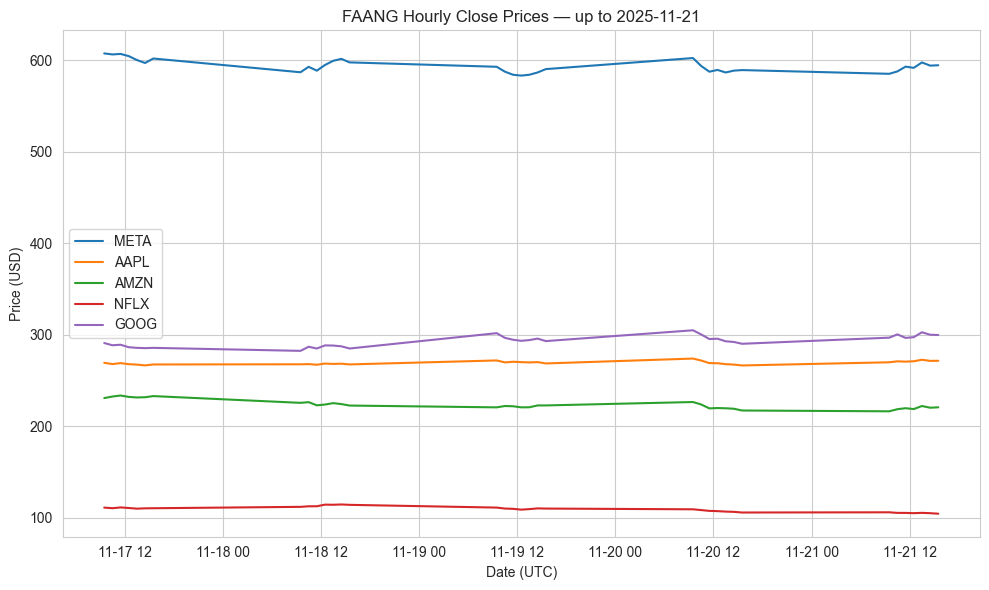

✅ Plot saved: plots\20251123-081447.png


In [11]:
def plot_data():
    tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
    # Load the latest dataset without preview
    data = load_latest_data(tickers, folder="data", show_preview=False)

    # Ensure plots directory exists
    PLOTS_DIR = Path("plots")
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    last_dates = []

    # Plot Close prices for each ticker
    for sym, df in data.items():
        if 'Date' in df.columns and 'Close' in df.columns and not df.empty:
            x = pd.to_datetime(df['Date'], errors='coerce')
            y = pd.to_numeric(df['Close'], errors='coerce')
            ax.plot(x, y, label=sym)
            last_dates.append(x.max())

    # Determine last available trading date for title
    title_date = "No data"
    if last_dates and pd.notnull(max(last_dates)):
        title_date = pd.to_datetime(max(last_dates)).strftime('%Y-%m-%d')

    # Add labels, legend, and title
    ax.set_title(f"FAANG Hourly Close Prices — up to {title_date}")
    ax.set_xlabel("Date (UTC)")
    ax.set_ylabel("Price (USD)")
    ax.legend()

    # Save plot with timestamped filename
    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    filename = PLOTS_DIR / f"{ts}.png"
    fig.tight_layout()
    fig.savefig(str(filename))

    # Display plot inline
    plt.show()
    print(f"✅ Plot saved: {filename}")

# Call the function
plot_data()


### 📌 Requirements Compliance Checklist

This section confirms that the notebook meets the assessment requirements for **Problem 1 (Data Collection)** and **Problem 2 (Visualisation)**.

**Problem 1: Data from yfinance**
- ✔ Function `get_data()` defined  
- ✔ Downloads **hourly OHLCV data** for the last 5 days  
- ✔ Covers FAANG tickers: META, AAPL, AMZN, NFLX, GOOG  
- ✔ Saves data into `data/` folder  
- ✔ Filenames follow format `YYYYMMDD-HHmmss.csv`  
- ✔ Creates `data/` folder automatically if missing  

**Problem 2: Plotting Data**
- ✔ Function `plot_data()` defined  
- ✔ Opens latest CSV file in `data/`  
- ✔ Plots hourly `Close` prices for all FAANG tickers on one chart  
- ✔ Adds axis labels, legend, and title with last available trading date  
- ✔ Saves plot into `plots/` folder with timestamped filename `YYYYMMDD-HHmmss.png`  
- ✔ Creates `plots/` folder automatically if missing  
- ✔ Displays plot inline in the notebook  

**Clarification:**  
All plotted values are **hourly closes**, not daily closes. Each point reflects the end of a one‑hour trading interval, exactly as required by the assignment.


## Step 8 — Optional Analysis Plots (Introductory Description)

This section introduces **optional, exploratory plots** that build on the Step 1 data dictionary and the derived `Return` and `RollingMean` columns from Step 6a. Each plot has its own short explanation cell and code cell.

### 📊 Upcoming Plots & Benefits

- **Step 8a — Histogram + KDE of Returns**  
  *Reveals the distribution shape, tails, and outliers for each ticker; useful for spotting non‑normality and extreme intraday moves.*

- **Step 8b — Pairwise Scatterplot Matrix (Pairplot)**  
  *Visualises pairwise relationships and joint distributions between tickers’ synchronous returns; highlights non‑linear relationships and niche clusters.*

- **Step 8c — Correlation Analysis (Hourly Returns)**  
  *Summarises linear co‑movement across tickers using Pearson correlation; compact view for diversification and risk discussion.*

- **Step 8d — Cumulative Returns vs Equal‑weight FAANG**  
  *Compares compounded performance of each ticker to a simple equal‑weight FAANG benchmark; shows relative outperformance and path differences.*

- **Step 8e — Rolling Average Plots**  
  *Overlays 30‑period moving averages on hourly closes; smooths short‑term noise to reveal longer‑term trends.*

### 📝 Usage Notes
- All plots read `Close` (and `Date`) from Step 1 frames.  
- Returns are computed from prices when missing.  
- Plots are **exploratory only** and do not modify saved files.  

### 📚 References
- [pandas pct_change](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.pct_change.html#pandas.core.groupby.DataFrameGroupBy.pct_change)
- [pandas rolling](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html)
- [seaborn plotting](https://seaborn.pydata.org/)  


### Step 8a — Histogram + KDE of Returns

This optional, display‑only cell plots a **histogram with KDE overlay** for each ticker’s hourly returns.

**What it does**  
- Ensures a valid `Return` column (computes `pct_change` from `Close` if missing).  
- Cleans NaNs from the returns series.  
- Plots one histogram + KDE per ticker, with the dataset’s last timestamp in the title.  

**Why it’s useful**  
*Reveals skew, tails, multimodality, and outliers; helps assess volatility and whether normality assumptions are reasonable.*  

**Notes for use**  
- Adjust bins or KDE bandwidth if needed.  
- KDE can be unstable for very small samples.  
- This cell is **exploratory only** and does not save files.  

**Reviewer hint**  
- Titles include the last available data date so plots can be traced back to the input CSV.  

**References**  
- [pandas pct_change](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pct_change.html)  
- [seaborn histplot / kdeplot](https://seaborn.pydata.org/)  


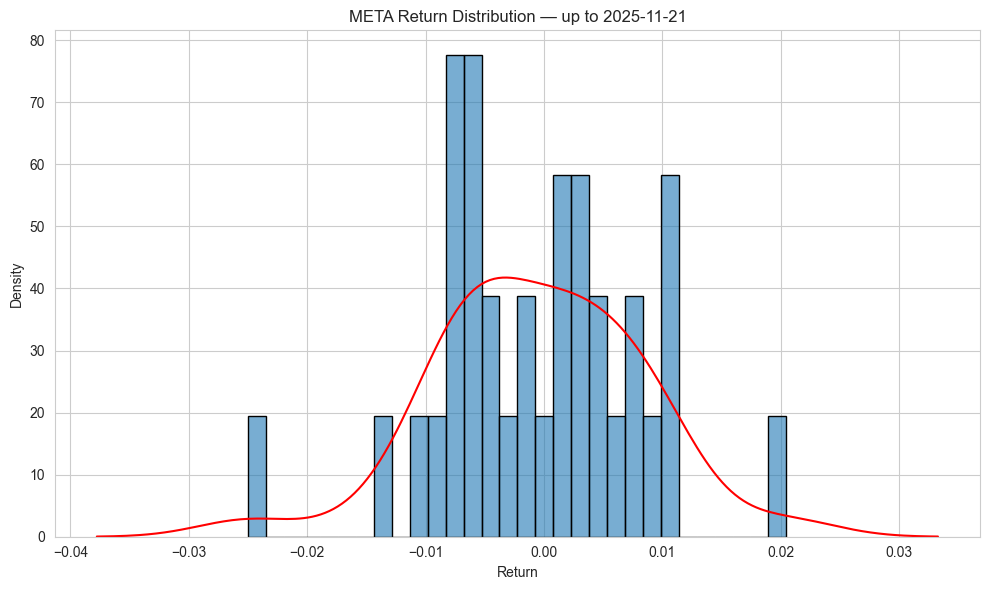

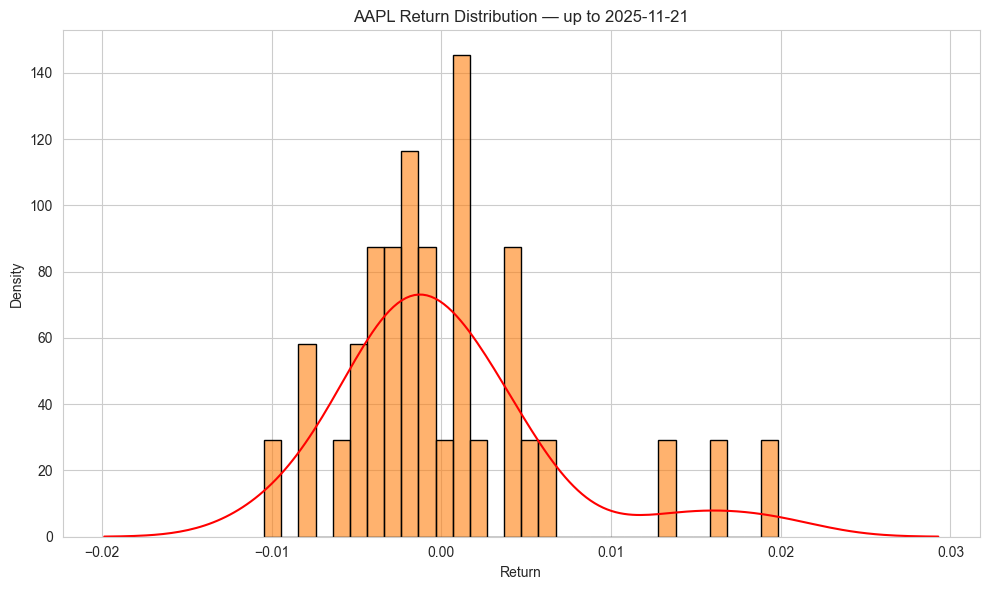

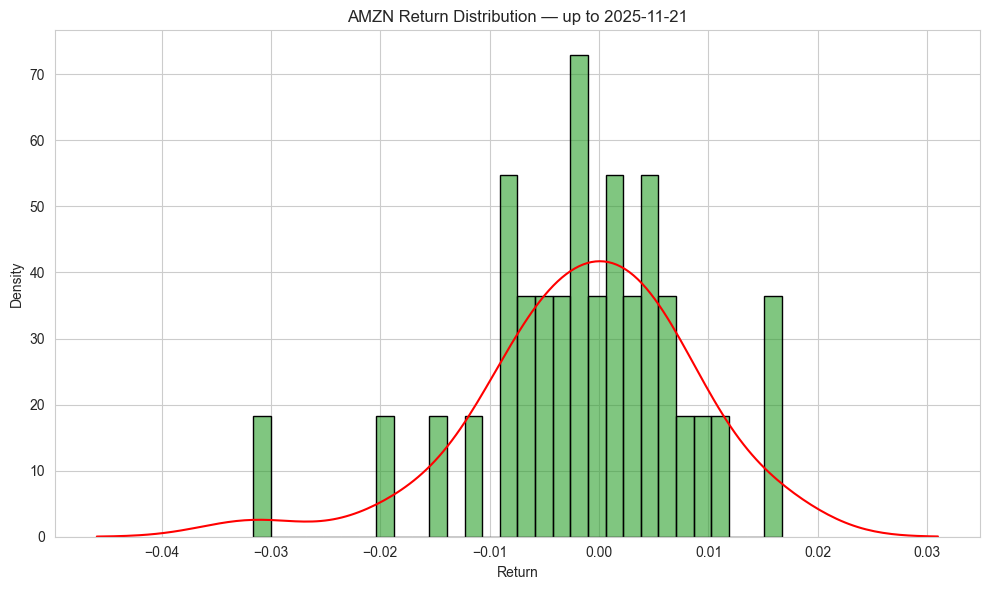

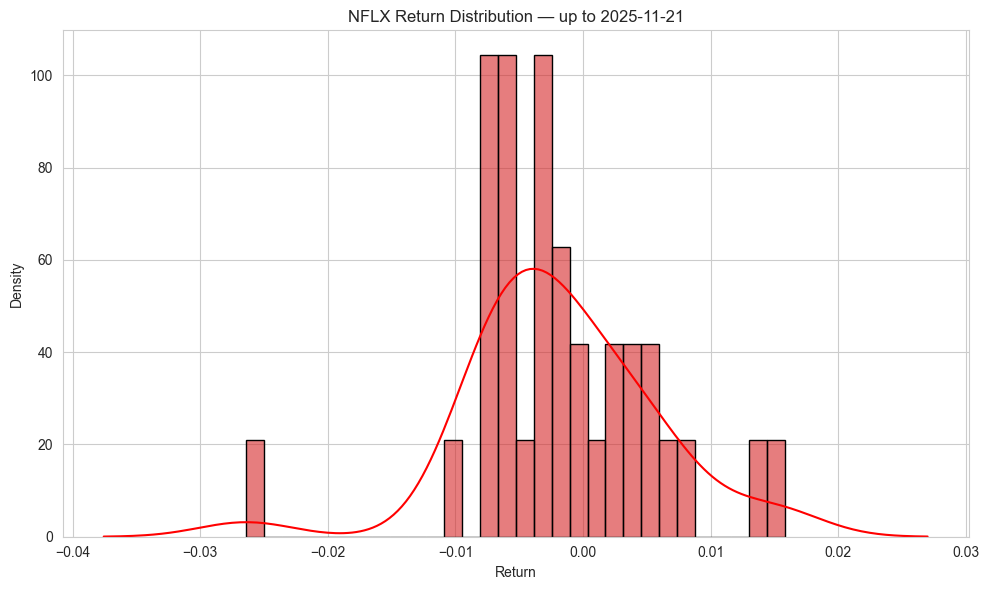

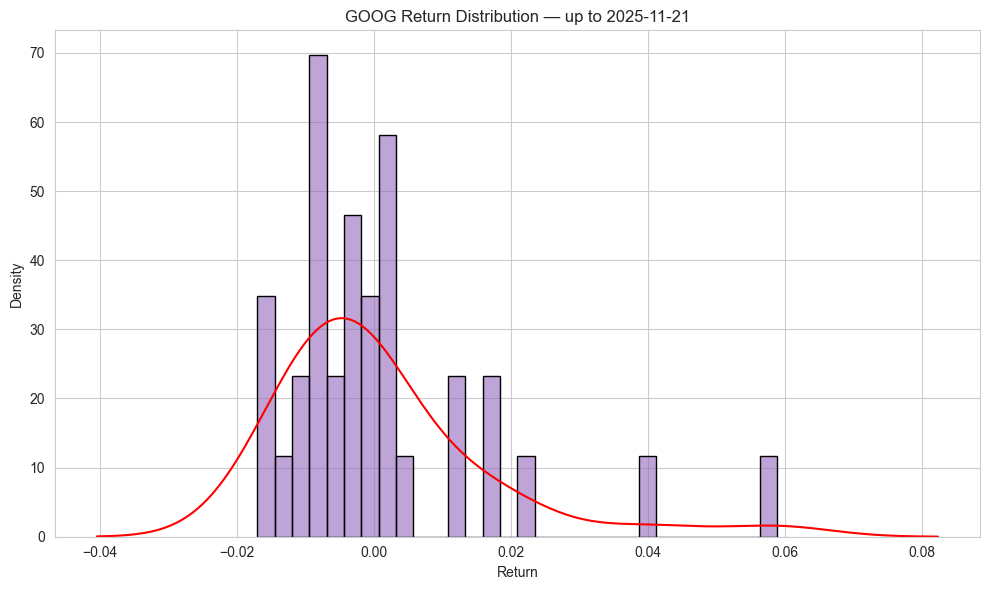

In [12]:
# Step 8a — Histogram + KDE of Returns (uses Step 1 `data`)

# Validate Step 1 `data`
if 'data' not in globals() or not isinstance(data, dict) or not data:
    raise RuntimeError("`data` (Step 1 downloads) not found or is empty. Ensure Step 1 populated `data` as dict[symbol -> DataFrame].")

palette = sns.color_palette("tab10", n_colors=len(data))

for i, (sym, df) in enumerate(data.items()):
    tmp = df.copy()
    # Expect Step 1 frames to have 'Close' (and optionally 'Date')
    if 'Close' not in tmp.columns:
        print(f"Skipping {sym}: no 'Close' column in Step 1 data.")
        continue

    # Compute Return from Close if missing (in-memory only)
    if 'Return' not in tmp.columns:
        tmp['Return'] = tmp['Close'].pct_change()
    returns = pd.to_numeric(tmp['Return'], errors='coerce').dropna()

    if returns.empty:
        print(f"{sym}: ⚠️ No valid returns to plot")
        continue

    # Determine last available date for plot title
    last_date = None
    if 'Date' in tmp.columns and not tmp['Date'].dropna().empty:
        last_date = pd.to_datetime(tmp['Date'], errors='coerce').max()
    elif not tmp.index.empty:
        last_date = pd.to_datetime(tmp.index, errors='coerce').max()
    title_date = pd.to_datetime(last_date).strftime("%Y-%m-%d") if last_date is not None else "No Data"

    # Plot histogram + KDE
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(x=returns, bins=30, stat="density", color=palette[i], ax=ax, edgecolor="k", alpha=0.6)
    sns.kdeplot(x=returns, color="red", ax=ax, linewidth=1.5)
    ax.set_title(f"{sym} Return Distribution — up to {title_date}")
    ax.set_xlabel("Return")
    ax.set_ylabel("Density")

    plt.tight_layout()
    plt.show()
    plt.close(fig)


### Step 8b — Pairwise Scatterplot Matrix (Pairplot)

This optional, display‑only cell generates **pairwise scatterplots with marginal KDEs** for synchronous hourly returns across FAANG tickers.

**What it does**  
- Aligns FAANG price series on common timestamps.  
- Computes synchronous hourly returns (`pct_change`).  
- Samples up to 1000 rows if the dataset is large, for performance.  
- Uses seaborn `pairplot` with `diag_kind="kde"` to show distributions on the diagonal and scatter panels off‑diagonal.  

**Why it’s useful**  
*Reveals linear relationships, non‑linear structure, and outliers that can affect correlations and diversification analysis.*  

**Notes**  
- Pairplots can be slow for large datasets; sampling limits to ~1000 rows.  
- This cell is **exploratory only** and does not save files.  

**Reviewer hint**  
- The plot title includes the last available data date so figures can be traced back to the input CSV.  

**References**  
- [pandas pct_change](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.pct_change.html#pandas.core.groupby.DataFrameGroupBy.pct_change)
- [seaborn pairplot](https://seaborn.pydata.org/)  


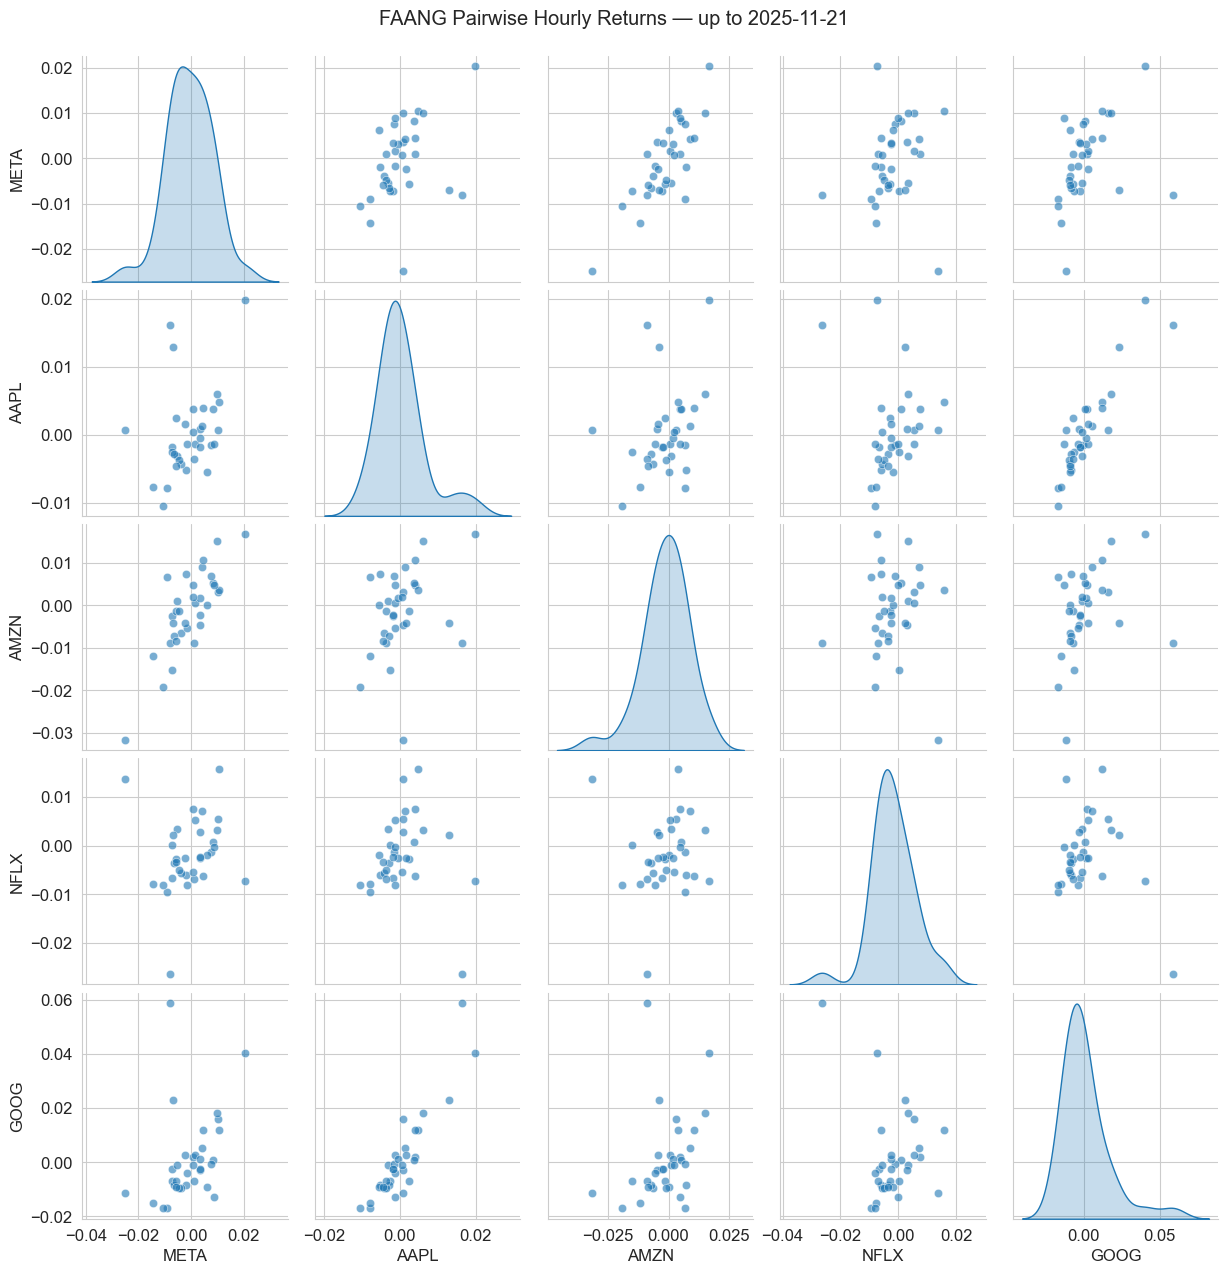

In [19]:
# Step 8b — Pairwise Scatterplot Matrix (Pairplot)

# Ensure data is loaded
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
if 'data' not in globals() or not isinstance(data, dict) or not data:
    print("`data` not found — reloading from Step 1 CSVs...")
    data = load_latest_data(tickers, folder="data", show_preview=False)

# Build aligned price series
aligned = []
for sym, df in data.items():
    tmp = df.copy()
    if 'Date' in tmp.columns and 'Close' in tmp.columns:
        tmp['Date'] = pd.to_datetime(tmp['Date'], errors='coerce')
        tmp = tmp.set_index('Date').sort_index()[['Close']]
    elif 'Close' in tmp.columns:
        tmp.index = pd.to_datetime(tmp.index, errors='coerce')
        tmp = tmp.sort_index()[['Close']]
    else:
        print(f"Skipping {sym}: no 'Close' column found in Step 1 data.")
        continue
    tmp = tmp.rename(columns={'Close': sym})
    aligned.append(tmp)

prices = pd.concat(aligned, axis=1, join='inner')
returns = prices.pct_change().dropna()

# Sample if dataset is large
if len(returns) > 1000:
    returns = returns.sample(1000, random_state=42)

# Generate pairplot across all tickers
sns.pairplot(returns, diag_kind="kde", plot_kws={"alpha":0.6})
plt.suptitle(f"FAANG Pairwise Hourly Returns — up to {prices.index.max().date()}", y=1.02)
plt.show()


### Step 8c — Correlation Analysis (Synchronous Hourly Returns)

This optional, display‑only cell computes and visualises **Pearson correlations** on synchronous hourly returns across FAANG tickers.  
Pearson correlation measures the strength and direction of linear relationships between returns, ranging from –1 (perfect negative) to +1 (perfect positive).

**What it does**  
- Sets `Date` as datetime index, sorts, and renames `Close` to ticker symbol.  
- Concatenates tickers with an inner join so only timestamps present for all tickers remain.  
- Computes synchronous returns via `pct_change()`, drops NaN rows, and calculates the correlation matrix.  
- Displays both the numeric matrix and an annotated heatmap.  

**Why this is better**  
*Correlating aligned returns avoids spurious results from non‑synchronous bars or trending price levels.*  
- Inner join is conservative: correlations reflect truly co‑observed hours.  
- Outer join with documented NaN handling can be used if broader coverage is required.  

**Practical checks**  
- Prints diagnostics (aligned shape and time range) so reviewers can see sample size.  
- If inner join yields too few rows, consider outer join plus careful imputation, or compute returns per ticker before alignment.  
- Correlations are sample‑dependent; always report time range and number of observations.  

**References**  
- [pandas pct_change](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.pct_change.html#pandas.core.groupby.DataFrameGroupBy.pct_change) 
- [seaborn heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)
- [Pearson correlation - wikipedia](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient)
- [Pearson correlation coefficient guide](https://www.scribbr.com/statistics/pearson-correlation-coefficient/)


Using Step 1 downloads. Aligned price matrix shape: (35, 5)
Time range: 2025-11-17 09:30:00-05:00 to 2025-11-21 15:30:00-05:00
Correlation matrix of synchronous hourly returns (from Step 1 data):


,META,AAPL,AMZN,NFLX,GOOG
META,1.000000,0.384118,0.802841,0.164806,0.381039
AAPL,0.384118,1.000000,0.331996,-0.029514,0.903033
AMZN,0.802841,0.331996,1.000000,0.040633,0.337289
NFLX,0.164806,-0.029514,0.040633,1.000000,-0.207838
GOOG,0.381039,0.903033,0.337289,-0.207838,1.000000


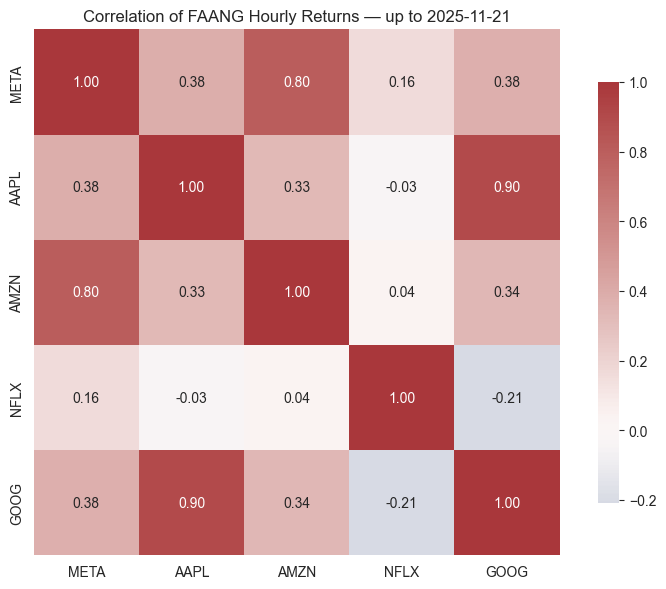

In [ ]:
# Step 8c — Correlation Analysis (uses Step 1 `data` downloads)

# Confirm `data` exists
if 'data' not in globals() or not isinstance(data, dict) or not data:
    raise RuntimeError("`data` (Step 1 downloads) not found or is empty.")

aligned = []
for sym, df in data.items():
    tmp = df.copy()
    # Expect 'Date' and 'Close' columns
    if 'Date' in tmp.columns and 'Close' in tmp.columns:
        tmp['Date'] = pd.to_datetime(tmp['Date'], errors='coerce')
        tmp = tmp.set_index('Date').sort_index()[['Close']]
    elif 'Close' in tmp.columns:
        tmp.index = pd.to_datetime(tmp.index, errors='coerce')
        tmp = tmp.sort_index()[['Close']]
    else:
        print(f"Skipping {sym}: no 'Close' column found.")
        continue
    tmp = tmp.rename(columns={'Close': sym})
    aligned.append(tmp)

if not aligned:
    raise RuntimeError("No valid price series found in `data`.")

# Inner join ensures synchronous timestamps across all tickers
prices = pd.concat(aligned, axis=1, join='inner')
if prices.empty:
    print("No overlapping timestamps; consider outer join with NaN handling.")
else:
    # Diagnostics
    print(f"Aligned price matrix shape: {prices.shape}")
    print(f"Time range: {prices.index.min()} to {prices.index.max()}")

    # Compute synchronous returns
    prices = prices.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
    returns = prices.pct_change().dropna()
    if returns.empty:
        print("No valid synchronous returns after pct_change and dropping NaNs.")
    else:
        corr = returns.corr()
        print("Correlation matrix of synchronous hourly returns:")
        display(corr)

        # Heatmap
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=ax, cbar_kws={"shrink": .8})
        ax.set_title(f"Correlation of FAANG Hourly Returns — up to {prices.index.max().date()}")
        plt.tight_layout()
        plt.show()
        plt.close(fig)


### Step 8d — Cumulative Returns vs Equal‑weight FAANG Benchmark

This optional, display‑only cell plots **cumulative hourly returns** for each FAANG ticker against a simple equal‑weight FAANG benchmark.

**What it does**  
- Aligns prices on common timestamps (inner join, Date as index, Close as columns).  
- Converts prices to numeric, computes synchronous returns via `pct_change()`, and drops NaN rows.  
- Builds an equal‑weight benchmark as the row‑wise mean of returns.  
- Computes cumulative returns as `(1 + r).cumprod() - 1` for each ticker and the benchmark.  
- Plots all cumulative return paths on one chart.  

**Why it’s useful**  
*Shows compounded performance paths and highlights relative outperformance versus a simple equal‑weight FAANG portfolio.*  
- Uses synchronous returns so plotted paths are directly comparable across tickers.  

**Reviewer guidance**  
- Prints aligned shape and time range for reproducibility.  
- To change the benchmark, replace the `benchmark_returns` series with your chosen proxy.  
- Optional: enable log scale for y‑axis to highlight relative growth rates.  

**References**  
- [pandas pct_change](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.pct_change.html#pandas.core.groupby.DataFrameGroupBy.pct_change)
- [pandas concat](https://pandas.pydata.org/docs/reference/api/pandas.concat.html#pandas.concat) 
- [Cumulative returns overview (Investopedia)](https://www.investopedia.com/terms/c/cumulativereturn.asp)  
- [Seaborn plotting](https://seaborn.pydata.org/)  
- [Matplotlib plotting](https://matplotlib.org/stable/contents.html)  


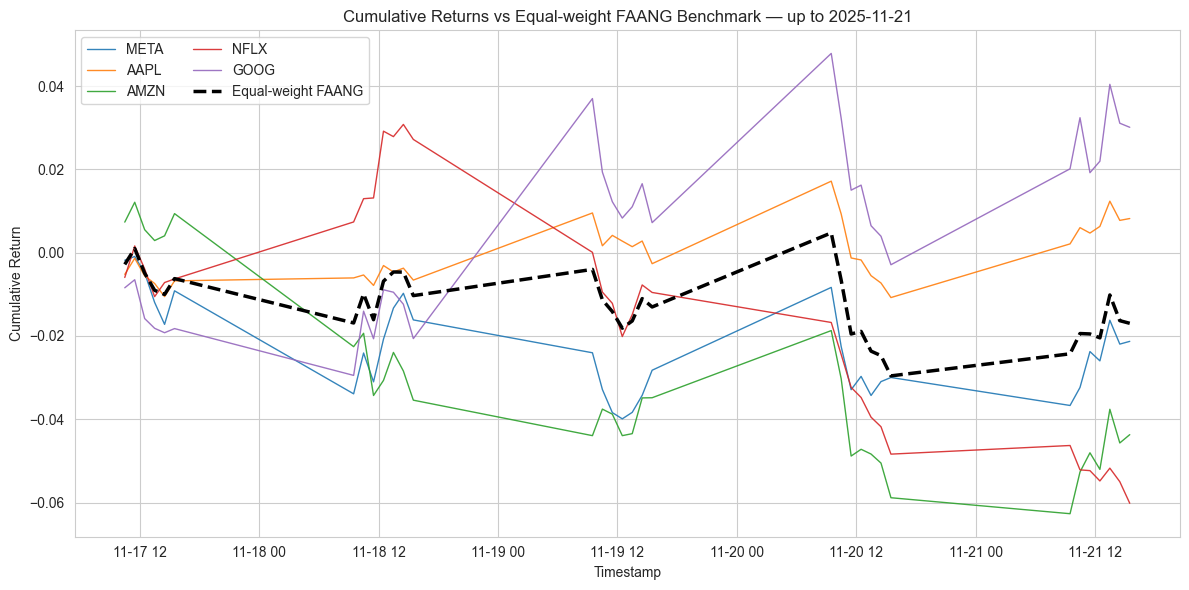

In [ ]:
# Step 8d — Cumulative Returns vs Equal-weight FAANG Benchmark

# 1) Build aligned price matrix (ticker columns) from data dict
aligned = []
for sym, df in data.items():
    tmp = df.copy()
    if 'Date' in tmp.columns:
        tmp['Date'] = pd.to_datetime(tmp['Date'], errors='coerce')
        tmp = tmp.set_index('Date').sort_index()
    else:
        tmp.index = pd.to_datetime(tmp.index, errors='coerce')
        tmp = tmp.sort_index()
    if 'Close' in tmp.columns:
        aligned.append(tmp[['Close']].rename(columns={'Close': sym}))

prices = pd.concat(aligned, axis=1, join='inner')  # inner join ensures synchronous timestamps

if prices.empty:
    print("No overlapping timestamps across tickers with inner join. Consider outer join + NaN handling.")
else:
    # 2) Ensure numeric and drop non-numeric columns
    prices = prices.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
    if prices.shape[1] == 0:
        print("No numeric price columns available after coercion.")
    else:
        # 3) Compute synchronous returns
        returns = prices.pct_change().dropna()
        if returns.empty:
            print("No valid synchronous returns after pct_change and dropping NaNs.")
        else:
            # 4) Build equal-weight benchmark
            benchmark_returns = returns.mean(axis=1)

            # 5) Compute cumulative returns
            cum_returns = (1 + returns).cumprod() - 1
            cum_benchmark = (1 + benchmark_returns).cumprod() - 1

            # 6) Plot cumulative returns vs benchmark
            fig, ax = plt.subplots(figsize=(12, 6))
            for col in cum_returns.columns:
                ax.plot(cum_returns.index, cum_returns[col], label=col, linewidth=1, alpha=0.9)
            ax.plot(cum_benchmark.index, cum_benchmark, label='Equal-weight FAANG', color='black', linewidth=2.5, linestyle='--')

            ax.set_title(f"Cumulative Returns vs Equal-weight FAANG Benchmark — up to {prices.index.max().date()}")
            ax.set_ylabel("Cumulative Return")
            ax.set_xlabel("Timestamp")
            ax.legend(loc='best', ncol=2)
            ax.grid(True)

            # Optional: enable log scale
            # ax.set_yscale('log')

            plt.tight_layout()
            plt.show()
            plt.close(fig)


### Step 8e — Rolling Average Plots

This optional, display‑only cell plots **hourly closing prices** for each FAANG ticker alongside a **30‑period rolling average**.

**What the code does**  
1. Reads each ticker’s DataFrame from Step 1 and uses the `Date` column (converted to datetime) for the x‑axis; falls back to the index if `Date` is missing.  
2. Uses an existing `RollingMean` column when present; otherwise computes an in‑memory 30‑period simple moving average from the `Close` series (without overwriting files).  
3. Plots both the `Close` series and the rolling average on the same axis, with clear titles and labels.  

**Why this is relevant to Step 1**  
*All plotted series are derived directly from the hourly `Close` prices downloaded in Step 1, ensuring visuals reflect the original fetched data and not a separate or ad‑hoc source.*  
- Rolling averages smooth short‑term fluctuations, making longer‑term trends easier to interpret.  

**Usage notes for reviewers**  
- Plots are **exploratory only** and do not modify saved CSVs or persist changes to Step 1 files.  
- The rolling window is set to 30 periods (hours); adjust if needed for different smoothing levels.  

**References**  
- [pandas rolling documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html)  
- [Moving averages overview (Investopedia)](https://www.investopedia.com/terms/m/movingaverage.asp)  
- [Matplotlib plotting](https://matplotlib.org/stable/contents.html)  


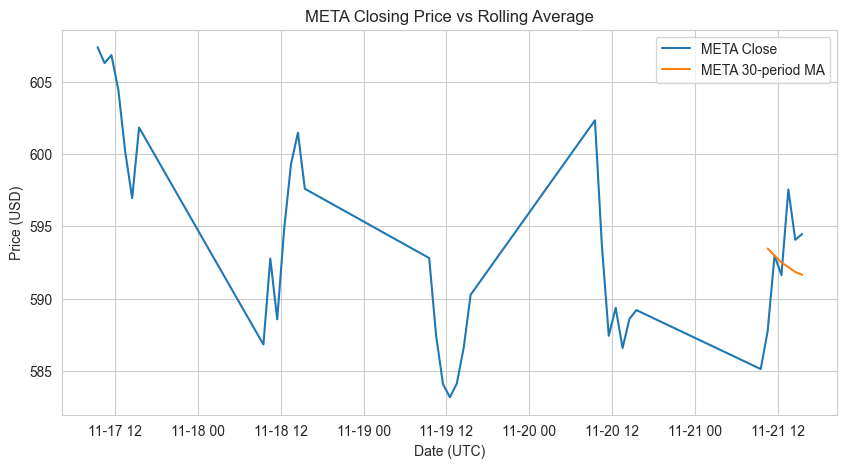

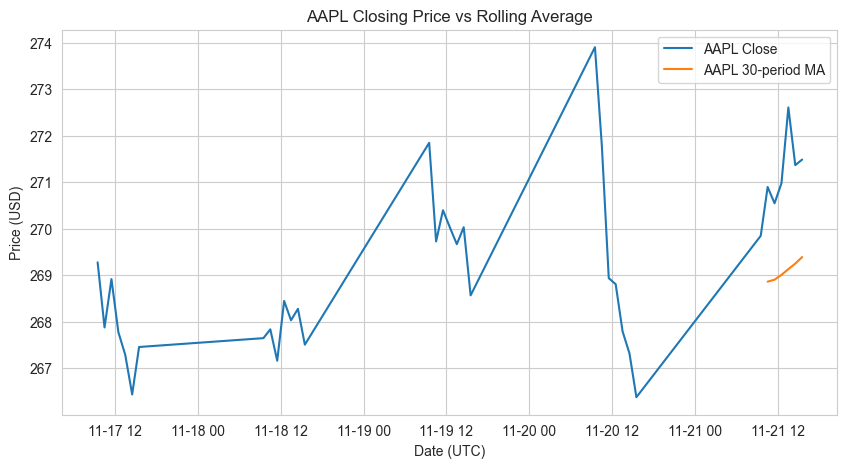

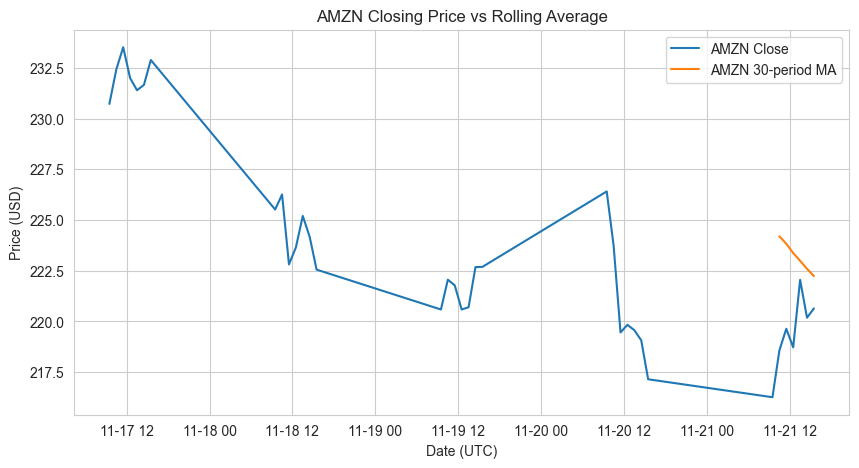

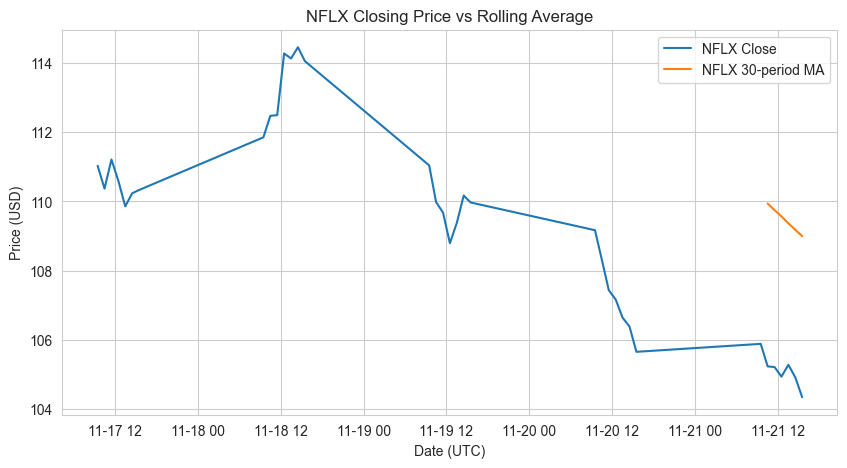

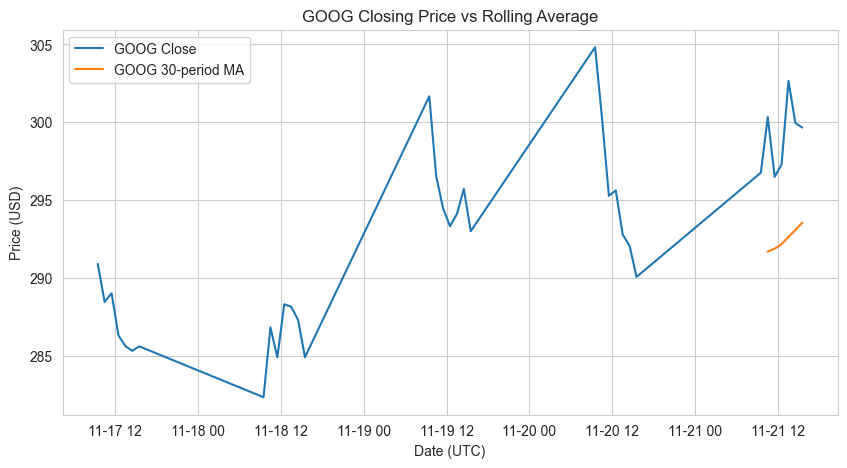

In [ ]:
# Step 8e — Rolling Average Plots
for sym, df in data.items():
    # Use Date column if available, else fallback to index
    if 'Date' in df.columns:
        x = pd.to_datetime(df['Date'], errors='coerce')
    else:
        x = pd.to_datetime(df.index, errors='coerce')

    # Use existing RollingMean if present, else compute in-memory
    if 'RollingMean' in df.columns:
        rm = df['RollingMean']
    else:
        rm = df['Close'].rolling(window=30).mean()

    # Plot Close vs Rolling Average
    plt.figure(figsize=(10, 5))
    plt.plot(x, df['Close'], label=f"{sym} Close")
    plt.plot(x, rm, label=f"{sym} 30-period MA")
    plt.title(f"{sym} Closing Price vs Rolling Average")
    plt.xlabel("Date (UTC)")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.show()


### Step 9 — Workflow Documentation

This section provides a concise summary of the notebook’s workflow and highlights reproducibility practices.

**Workflow demonstrated**
1. **Fetching hourly FAANG data** (`get_data`)  
   *Downloads and saves hourly Close prices for META, AAPL, AMZN, NFLX, GOOG.*
2. **Loading and validating latest downloads** (`load_latest_data`)  
   *Ensures data integrity and prepares aligned DataFrames.*
3. **Previewing and summarising datasets**  
   *Sanity checks, dtypes, and missingness diagnostics.*
4. **Plotting closing prices** (`plot_data`)  
   *Generates labelled plots of hourly Close series.*
5. **Extended visualisations**  
   *Returns, rolling means, histograms, boxplots, pairplots.*
6. **Correlation analysis on synchronous returns**  
   *Aligns timestamps, computes Pearson correlations, and displays heatmaps.*
7. **Comparative performance**  
   *Plots cumulative returns vs equal‑weight FAANG benchmark.*
8. **Notebook‑level documentation**  
   *Usage notes, reviewer guidance, and references.*

**Quick reviewer notes**
- Each analysis step documents inputs, alignment choices (inner vs outer join), and any imputation used.  
- Diagnostic outputs (shapes, time ranges, co‑observation counts) are printed before key computations to ensure reproducibility.  

**References**  
- [pandas User Guide](https://pandas.pydata.org/docs/user_guide/index.html)  
- [Matplotlib documentation](https://matplotlib.org/stable/contents.html)  
- [Seaborn documentation](https://seaborn.pydata.org/)  


### Problem 3 – Create a CLI Script (`faang.py`)

To meet Problem 3, I created a standalone Python script `faang.py` at the repository root that automates hourly FAANG data download and plotting. The notebook now includes execution controls to prevent duplicate outputs when both the script and notebook are used.

**Modularisation:** Core helpers ('fetch_hourly_history', 'save_hourly_data', 'load_latest_data', 'plot_close_prices') live in faang.py and are reused by the notebook for consistency and maintainability.

**Script behavior:** The script runs Problems 1–3 in sequence via main() when executed from the terminal. It produces exactly one CSV (in data/) and one plot (in plots/) per run.

**Notebook controls:** The notebook cell provides flags to control execution.

**RUN_PROBLEM_1:''** When False, no new CSV is generated in the notebook, *set to True to enable running problem 1 within the notebook*.

**RUN_PROBLEM_2:** When False, no plot is generated in the notebook. *Set to True to enable running problem 2 within the notebook*.

These default to False to avoid duplication if the script is also executed.

**Title accuracy:** The plot title reflects the last available trading date from the dataset, aligning the visualisation with yfinance’s hourly data availability.

This implementation allows the script to be run with:
```bash
./faang.py --plot
```

Relevant to: **Problem 3 (Script Creation)**

**Optional analysis steps** from the notebook (such as summary statistics, data quality checks, rolling means, extended visualisations, and correlation analysis) were intentionally excluded from the script to keep it aligned with the assessment guidelines. These remain in the notebook as supplementary exploration only.

References:

- [Assessment Instructions – Computer Infrastructure](https://github.com/ianmcloughlin/computer-infrastructure/blob/main/assessment/problems.md)
- [Python CLI Design with argparse](https://realpython.com/command-line-interfaces-python-argparse/)  
- [Shebang Line Usage](https://realpython.com/python-shebang/)



In [17]:
# 🐍 faang.py — Script Code Cell (Notebook version with execution controls)

# -------------------------------------------------
# Notebook execution controls:
# Set these flags to control whether the notebook generates a new CSV (Problem 1)
# and/or produces the plot (Problem 3). Both default to False to prevent duplication
# when the standalone script (faang.py) is also executed externally.
RUN_PROBLEM_1 = False   # ✅ Default False — do NOT fetch/save a new CSV unless explicitly enabled
RUN_PROBLEM_2 = False   # ✅ Default False — do NOT plot unless explicitly enabled

#!/usr/bin/env python3
"""
faang.py — Assessment Script for FAANG Stock Analysis — Winter 25/26 Assessment

Author: Edward Cronin

Implements:
- Problem 1: Fetch FAANG hourly data (last 5 days) and save to CSV.
- Problem 2: Plot FAANG hourly closing prices from latest CSV and save to PNG.
- Problem 3: Executable script that runs both steps when called from terminal.

Notes:
- 'Close' refers to the price at the end of each hourly interval, not the final daily close.
- The yfinance API only provides hourly data up to the most recent trading day.
  • On weekdays when markets are open, the script captures hourly closes intraday.
  • On weekends or holidays, no new hourly data is available, so the latest file stops
    at the final close of the last trading session (e.g., Friday’s market close).
- The chart title has been updated to reflect the last available trading date in the dataset,
  ensuring consistency between the plot and the underlying data.
- This aligns with the assignment requirement to fetch 5 days of hourly data.
"""

from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
DATA_DIR = Path("data").resolve()
PLOTS_DIR = Path("plots").resolve()
TICKERS = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']

DATA_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Apply notebook-style aesthetics for consistency
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 12

# --- Helper Functions ---
def fetch_hourly_history(ticker):
    """Fetch hourly FAANG data for the last 5 days."""
    df = yf.Ticker(ticker).history(period='5d', interval='1h')
    if df.empty:
        print(f"⚠️ No data for {ticker}")
        return None
    df['Ticker'] = ticker
    df.index.name = 'Date'
    return df

def save_hourly_data(tickers, output_dir):
    """Save combined FAANG data into data/ folder with timestamped filename."""
    dfs = []
    for t in tickers:
        df = fetch_hourly_history(t)
        if df is not None and not df.empty:
            dfs.append(df)
            print(f"✅ {t}: {len(df)} rows")
        else:
            print(f"⚠️ {t}: No valid data")

    if not dfs:
        print("🚫 No valid data to save.")
        return None

    final_df = pd.concat(dfs)
    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    path = output_dir / f"{ts}.csv"
    final_df.to_csv(path, index_label='Date')
    print(f"✅ Data saved to {path}")
    return str(path)

def load_latest_data(tickers, folder='data'):
    """Load the most recent CSV from data/ folder and split into ticker DataFrames."""
    files = sorted(Path(folder).glob("*.csv"), reverse=True)
    if not files:
        print("🚫 No CSV files found.")
        return {}

    df = pd.read_csv(files[0], parse_dates=["Date"])
    data = {t: df[df["Ticker"] == t].copy() for t in tickers}
    return data

def plot_close_prices(data, output_dir, show=False):
    """Plot hourly closing prices for FAANG tickers and save to plots/ folder."""
    fig, ax = plt.subplots()
    plotted = False
    last_date = None

    for sym, df in data.items():
        if 'Close' in df.columns and not df.empty:
            x = pd.to_datetime(df['Date'], errors='coerce')
            y = df['Close']
            ax.plot(x, y, label=sym)
            plotted = True
            # Track the latest date across tickers
            if last_date is None or df['Date'].max() > last_date:
                last_date = df['Date'].max()

    ax.set_xlabel("Date")
    ax.set_ylabel("Close Price (USD)")

    if plotted:
        ax.legend(title="Ticker", loc="best")

    # ✅ Use the last available date from the dataset for the title
    if last_date is not None:
        title_date = pd.to_datetime(last_date).strftime("%Y-%m-%d")
        ax.set_title(f"FAANG Hourly Closing Prices — up to {title_date}")
    else:
        ax.set_title("FAANG Hourly Closing Prices — No Data")

    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    plot_path = output_dir / f"{ts}.png"
    fig.tight_layout()
    fig.savefig(plot_path, bbox_inches='tight')
    print(f"✅ Plot saved to {plot_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

# --- Notebook-controlled Execution ---
def main():
    """Run data download and plotting in sequence (Problems 1–3), controlled by flags."""
    saved_file = None

    # Problem 1 — Fetch and save CSV (optional)
    if RUN_PROBLEM_1:
        saved_file = save_hourly_data(TICKERS, DATA_DIR)
        if not saved_file:
            print("🚫 No data file saved. Exiting.")
            return
    else:
        print("ℹ️ Problem 1 skipped — CSV not generated (RUN_PROBLEM_1 = False).")

    # Problem 2 — Load latest CSV (only if we plan to plot or if reviewer wants to check data)
    data = {}
    if RUN_PROBLEM_2:
        data = load_latest_data(TICKERS, folder=str(DATA_DIR))
        if not data:
            print("🚫 No CSV available to load for plotting. Enable RUN_PROBLEM_1 or ensure a CSV exists.")
            return

    # Problem 3 — Plot (optional)
    if RUN_PROBLEM_2:
        plot_close_prices(data, PLOTS_DIR, show=True)
    else:
        print("ℹ️ Problem 3 skipped — set RUN_PROBLEM_2 = True to generate and display the plot.")

if __name__ == "__main__":
    main()


ℹ️ Problem 1 skipped — CSV not generated (RUN_PROBLEM_1 = False).
ℹ️ Problem 3 skipped — set RUN_PROBLEM_2 = True to generate and display the plot.


### Summary and Transition to Problem 4

With the CLI script `faang.py` now complete, Problem 3 is fully addressed. The script is modular, executable from the terminal, and supports flexible command-line arguments for downloading data and generating plots. It consolidates the notebook’s logic into a reusable tool that can be run manually or integrated into automated workflows.

Next, in **Problem 4**, I will configure a GitHub Actions workflow to run `faang.py` on a schedule. This will automate the data collection and visualization process, ensuring fresh stock data and updated plots are generated regularly without manual intervention.

Relevant to: Problem 4 (Automation)

Reference: [Assessment Instructions – Computer Infrastructure](https://github.com/ianmcloughlin/computer-infrastructure/blob/main/assessment/problems.md)
